In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame({
    "x": rng.normal(50, 10, n),
    "female": rng.binomial(1, 0.52, n),
})
lp = -1.5 + 0.03 * df["x"] - 0.3 * df["female"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ x + female", data=df,
              family=sm.families.Binomial()).fit()
m = GComputation(fit, at="overall", scale="identity")

In [2]:
# Full elasticity at the estimator's `at` setting
print(m.eyex("x").summary())

# Semi-elasticities
print(m.eydx("x").summary())
print(m.dyex("x").summary())

              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eyex(x)    0.8661   0.1355  6.3914  0.000    0.6005, 1.1316

n = 2000
Delta-vs-sim disagreement: 3.117%
plan 0d0505f@1 | κ = 0.028
              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eydx(x)    0.0175   0.0028  6.2337  0.000    0.0120, 0.0230

n = 2000
Delta-vs-sim disagreement: 6.565%
plan 0d0505f@1 | κ = 0.046
              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
dyex(x)    0.3858   0.0482  7.9979  0.000    0.2913, 0.4804

n = 2000
Delta-vs-sim disagreement: 2.780%
plan 0d0505f@1 | κ = 0.020


In [3]:
# Elasticity of x within each level of female
print(m.eyex("x", over="female").summary())

              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eyex(x)    0.7960   0.1470  5.4161  0.000    0.5079, 1.0840
[1]        0.9429   0.1420  6.6381  0.000    0.6645, 1.2213

n = 2000
Delta-vs-sim disagreement: 10.989%
plan 0d0505f@1 | κ = max 0.091


In [4]:
x_bar = df["x"].mean()
y_bar = m.predict().estimate.item()

# eyex via scaled()
print(m.dydx("x").scaled(by=x_bar / y_bar).summary())

                     Graph Result (delta, level=0.95)                    
                       estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------------
(x)*110.9958295306184    0.8661   0.1340  6.4625  0.000    0.6034, 1.1287

n = 2000
Delta-vs-sim disagreement: 4.196%
plan 0d0505f@1 | κ = 0.033


In [5]:
import numpy as np

res = m.eyex("x", over="female")
print(res.summary())

# Difference in elasticities with a proper SE
diff = res.contrast(np.array([[1, -1]]), labels=["female=1 - female=0"])
print(diff.summary())

              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eyex(x)    0.7960   0.1470  5.4161  0.000    0.5079, 1.0840
[1]        0.9429   0.1420  6.6381  0.000    0.6645, 1.2213

n = 2000
Delta-vs-sim disagreement: 9.753%
plan 0d0505f@1 | κ = max 0.091


                    Graph Result (delta, level=0.95)                    
                     estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------------------
female=1 - female=0   -0.1469   0.0369  -3.9819  0.000  -0.2192, -0.0746

n = 2000
Delta-vs-sim disagreement: 9.753%
plan 0d0505f@1 | κ = max 0.091


[Text(0, 0.5, 'Elasticity of x')]

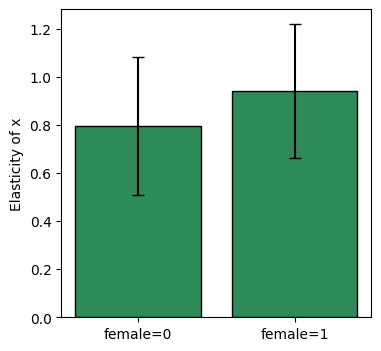

In [6]:
import matplotlib.pyplot as plt

df_res = res.to_frame()

labels = ["female=0", "female=1"]
estimates = df_res["estimate"].tolist()
ci_lower = df_res["ci_lower"].tolist()
ci_upper = df_res["ci_upper"].tolist()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(labels, estimates,
       yerr=[np.array(estimates) - np.array(ci_lower),
             np.array(ci_upper) - np.array(estimates)],
       capsize=4, color="seagreen", edgecolor="black")
ax.set(ylabel="Elasticity of x")